# Model Comparison

## Objective

The objective of this notebook is to compare the performance of all machine learning models developed for Just-In-Time Software Bug Prediction.

Models Evaluated:

1. Logistic Regression
2. Random Forest
3. XGBoost

The models are compared using:

- Accuracy
- Precision
- Recall
- F1 Score
- ROC-AUC

The goal is to identify the best-performing model for commit-level defect prediction.

In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("default")

In [ ]:
comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "XGBoost"
    ],
    "Accuracy": [
        0.692383,
        0.681837,
        0.721631
    ],
    "Precision": [
        0.304552,
        0.315678,
        0.339450
    ],
    "Recall": [
        0.686443,
        0.809688,
        0.742333
    ],
    "F1 Score": [
        0.421915,
        0.454253,
        0.465869
    ],
    "ROC AUC": [
        0.761170,
        0.808421,
        0.803052
    ]
})

comparison

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC
0,Logistic Regression,0.692383,0.304552,0.686443,0.421915,0.761170
1,Random Forest,0.681837,0.315678,0.809688,0.454253,0.808421
2,XGBoost,0.721631,0.339450,0.742333,0.465869,0.803052


In [ ]:
comparison.to_csv(
    "/content/drive/MyDrive/JIT_bug_prediction/outputs/tables/model_comparison.csv",
    index=False
)

print("Comparison table saved.")

Comparison table saved.


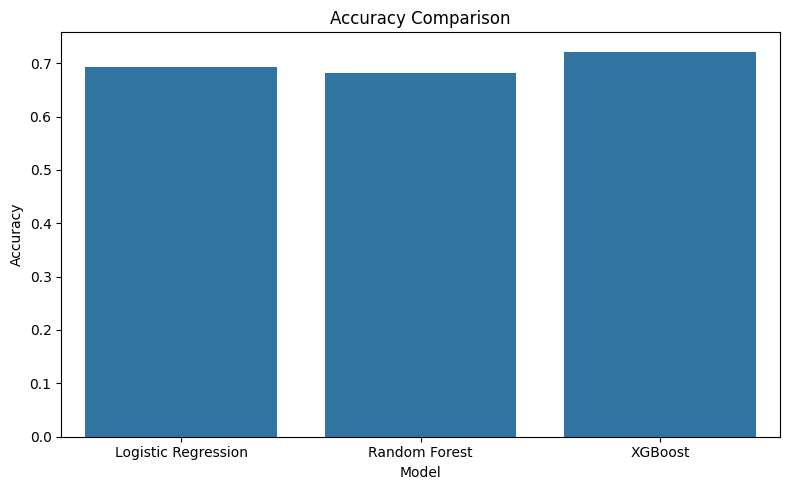

In [ ]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=comparison,
    x="Model",
    y="Accuracy"
)

plt.title("Accuracy Comparison")

plt.tight_layout()

plt.savefig(
    "/content/drive/MyDrive/JIT_bug_prediction/outputs/plots/comparison_accuracy.png"
)

plt.show()

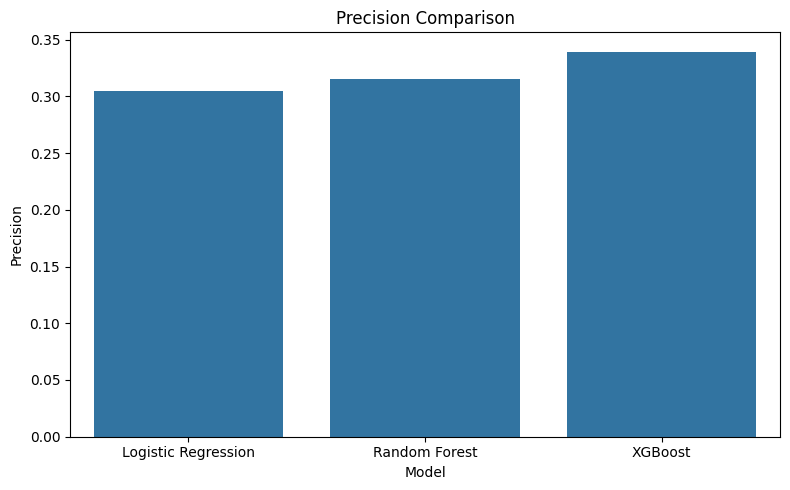

In [ ]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=comparison,
    x="Model",
    y="Precision"
)

plt.title("Precision Comparison")

plt.tight_layout()

plt.savefig(
    "/content/drive/MyDrive/JIT_bug_prediction/outputs/plots/comparison_precision.png"
)

plt.show()

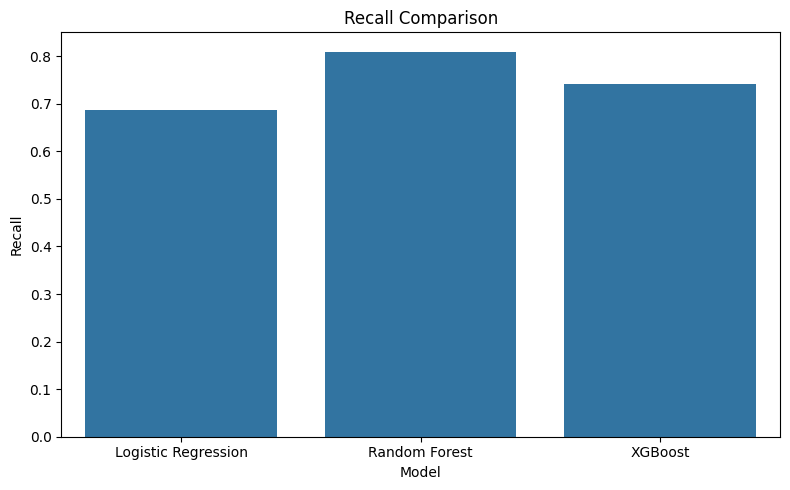

In [ ]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=comparison,
    x="Model",
    y="Recall"
)

plt.title("Recall Comparison")

plt.tight_layout()

plt.savefig(
    "/content/drive/MyDrive/JIT_bug_prediction/outputs/plots/comparison_recall.png"
)

plt.show()

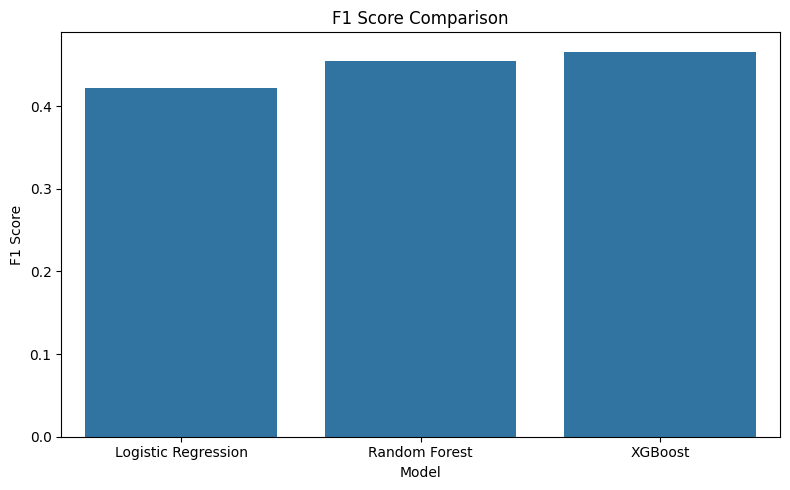

In [ ]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=comparison,
    x="Model",
    y="F1 Score"
)

plt.title("F1 Score Comparison")

plt.tight_layout()

plt.savefig(
    "/content/drive/MyDrive/JIT_bug_prediction/outputs/plots/comparison_f1.png"
)

plt.show()

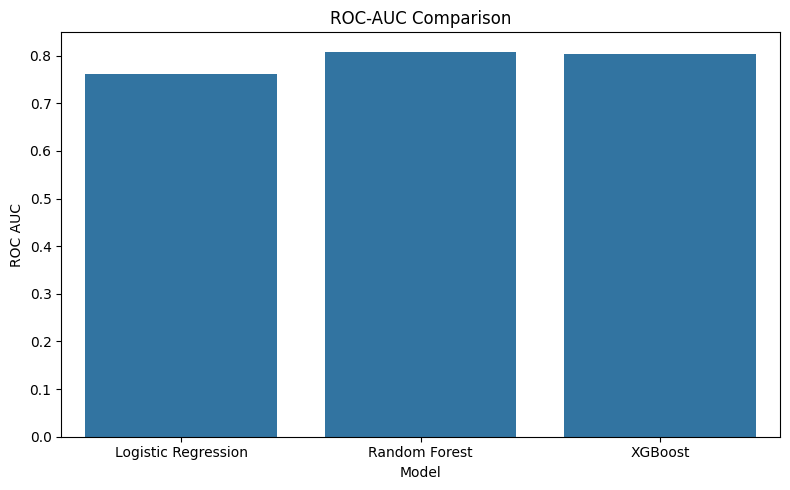

In [ ]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=comparison,
    x="Model",
    y="ROC AUC"
)

plt.title("ROC-AUC Comparison")

plt.tight_layout()

plt.savefig(
    "/content/drive/MyDrive/JIT_bug_prediction/outputs/plots/comparison_auc.png"
)

plt.show()

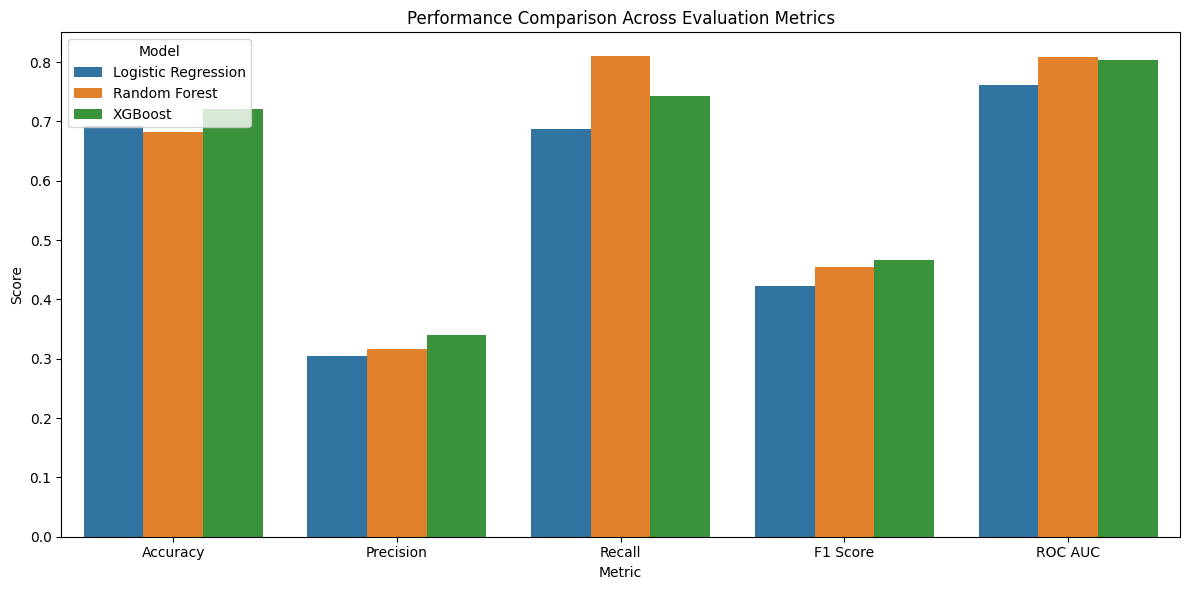

In [ ]:
comparison_melted = comparison.melt(
    id_vars="Model",
    var_name="Metric",
    value_name="Score"
)

plt.figure(figsize=(12,6))

sns.barplot(
    data=comparison_melted,
    x="Metric",
    y="Score",
    hue="Model"
)

plt.title(
    "Performance Comparison Across Evaluation Metrics"
)

plt.tight_layout()

plt.savefig(
    "/content/drive/MyDrive/JIT_bug_prediction/outputs/plots/grouped_metrics_comparison.png"
)

plt.show()

In [ ]:
comparison

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC
0,Logistic Regression,0.692383,0.304552,0.686443,0.421915,0.761170
1,Random Forest,0.681837,0.315678,0.809688,0.454253,0.808421
2,XGBoost,0.721631,0.339450,0.742333,0.465869,0.803052


# Findings

## Performance Summary

| Metric | Logistic Regression | Random Forest | XGBoost |
|----------|----------|----------|----------|
| Accuracy | 69.24% | 68.18% | 72.16% |
| Precision | 30.46% | 31.57% | 33.95% |
| Recall | 68.64% | 80.97% | 74.23% |
| F1 Score | 42.19% | 45.43% | 46.59% |
| ROC-AUC | 0.7612 | 0.8084 | 0.8031 |

---

## Logistic Regression

Logistic Regression was implemented as the baseline model for Just-In-Time defect prediction.

The model achieved reasonable performance and demonstrated the feasibility of predicting defect-inducing commits using commit-level software metrics. However, its linear nature limited its ability to capture complex interactions among software change features.

The model achieved the lowest F1 Score and ROC-AUC among all evaluated approaches and therefore serves primarily as a benchmark for comparison.

---

## Random Forest

Random Forest significantly improved the predictive performance over the baseline model.

The ensemble-based approach successfully captured non-linear relationships between software metrics and defect proneness, resulting in substantial gains in Recall and ROC-AUC.

With a Recall of 80.97%, Random Forest detected the highest proportion of bug-inducing commits among all evaluated models, making it highly effective for defect detection scenarios where missing a bug is costly.

---

## XGBoost

XGBoost demonstrated the strongest overall classification performance.

The model achieved the highest Accuracy, Precision, and F1 Score while maintaining a competitive Recall and ROC-AUC.

The results indicate that gradient boosting effectively learns complex patterns within software engineering metrics and provides a better balance between detecting buggy commits and reducing false positives.

---

## ROC-AUC Analysis

ROC-AUC was used to evaluate the discriminative capability of each model.

Random Forest achieved the highest ROC-AUC score of 0.8084, indicating the strongest ability to distinguish between buggy and non-buggy commits.

XGBoost achieved a very similar ROC-AUC score of 0.8031 while simultaneously providing higher Accuracy, Precision, and F1 Score.

Both ensemble learning methods substantially outperformed Logistic Regression, demonstrating the effectiveness of advanced tree-based learning algorithms for Just-In-Time defect prediction.

---

## Comparative Discussion

The experimental results reveal a clear performance progression across the evaluated models.

- Logistic Regression established a strong baseline.
- Random Forest substantially improved bug detection capability.
- XGBoost delivered the best overall balance between Precision and Recall.

While Random Forest achieved the highest Recall and ROC-AUC, XGBoost produced fewer false positives and achieved the strongest overall F1 Score.

This trade-off is particularly important in practical software development environments where excessive false alarms may reduce developer trust in prediction systems.

---

## Final Model Selection

Based on the overall experimental evaluation:

- Highest Accuracy (72.16%)
- Highest Precision (33.95%)
- Highest F1 Score (46.59%)
- Competitive Recall (74.23%)
- Competitive ROC-AUC (0.8031)

XGBoost is selected as the final recommended model for Just-In-Time Software Bug Prediction on the ApacheJIT dataset.

---

## Conclusion

This study demonstrates that ensemble learning techniques significantly outperform traditional linear models for commit-level defect prediction.

Among the evaluated approaches, XGBoost provides the most balanced and reliable performance, achieving superior classification effectiveness while maintaining strong discriminative capability.

Therefore, XGBoost is chosen as the final model for subsequent explainability analysis, interpretation, and future deployment within the proposed Just-In-Time Bug Prediction framework.